In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

np.random.seed(42)
N_SAMPLES = 100_000
ALPHA_PRIOR, BETA_PRIOR = 1, 1
COLORS = {'gate_30': '#378ADD', 'gate_40': '#EF9F27'}

ab = pd.read_csv('../app/ab_counts.csv')
print(ab.to_string(index=False))

version     outcome     n  successes  failures     rate
gate_30 retention_1 44700      20034     24666 0.448188
gate_40 retention_1 45489      20119     25370 0.442283
gate_30 retention_7 44700       8502     36198 0.190201
gate_40 retention_7 45489       8279     37210 0.182000


In [2]:
def bayesian_ab(ab_df, outcome, alpha_prior=1, beta_prior=1, n_samples=100_000):
    sub = ab_df[ab_df['outcome'] == outcome]
    a = sub[sub['version'] == 'gate_30'].iloc[0]
    b = sub[sub['version'] == 'gate_40'].iloc[0]

    # Posterior: Beta(prior + successes, prior + failures)
    post_30 = stats.beta(alpha_prior + a['successes'], beta_prior + a['failures'])
    post_40 = stats.beta(alpha_prior + b['successes'], beta_prior + b['failures'])

    # Monte Carlo sampling
    samples_30 = post_30.rvs(n_samples, random_state=42)
    samples_40 = post_40.rvs(n_samples, random_state=99)

    diff = samples_40 - samples_30  # B - A

    return {
        'outcome': outcome,
        'samples_30': samples_30,
        'samples_40': samples_40,
        'diff': diff,
        # P(gate_30 > gate_40) — câu hỏi chính
        'p_30_wins': (samples_30 > samples_40).mean(),
        'p_40_wins': (samples_40 > samples_30).mean(),
        # Credible interval cho diff (B - A)
        'ci_low':  np.percentile(diff, 2.5),
        'ci_high': np.percentile(diff, 97.5),
        'diff_mean': diff.mean(),
        # Expected loss — giá trị kỳ vọng mất nếu chọn sai
        'expected_loss_if_choose_40': np.mean(np.maximum(samples_30 - samples_40, 0)),
        'expected_loss_if_choose_30': np.mean(np.maximum(samples_40 - samples_30, 0)),
    }

results = {o: bayesian_ab(ab, o) for o in ['retention_1', 'retention_7']}

# Print summary
for outcome, r in results.items():
    print(f"=== {outcome} ===")
    print(f"  P(gate_30 > gate_40): {r['p_30_wins']:.4f} ({r['p_30_wins']*100:.2f}%)")
    print(f"  P(gate_40 > gate_30): {r['p_40_wins']:.4f} ({r['p_40_wins']*100:.2f}%)")
    print(f"  Diff mean (B-A):      {r['diff_mean']:+.5f}")
    print(f"  95% Credible Interval: [{r['ci_low']:+.5f}, {r['ci_high']:+.5f}]")
    print(f"  Expected loss chọn gate_40: {r['expected_loss_if_choose_40']:.5f}")
    print(f"  Expected loss chọn gate_30: {r['expected_loss_if_choose_30']:.5f}")
    print()



=== retention_1 ===
  P(gate_30 > gate_40): 0.9629 (96.29%)
  P(gate_40 > gate_30): 0.0371 (3.71%)
  Diff mean (B-A):      -0.00592
  95% Credible Interval: [-0.01238, +0.00061]
  Expected loss chọn gate_40: 0.00597
  Expected loss chọn gate_30: 0.00005

=== retention_7 ===
  P(gate_30 > gate_40): 0.9994 (99.94%)
  P(gate_40 > gate_30): 0.0006 (0.06%)
  Diff mean (B-A):      -0.00821
  95% Credible Interval: [-0.01326, -0.00316]
  Expected loss chọn gate_40: 0.00821
  Expected loss chọn gate_30: 0.00000



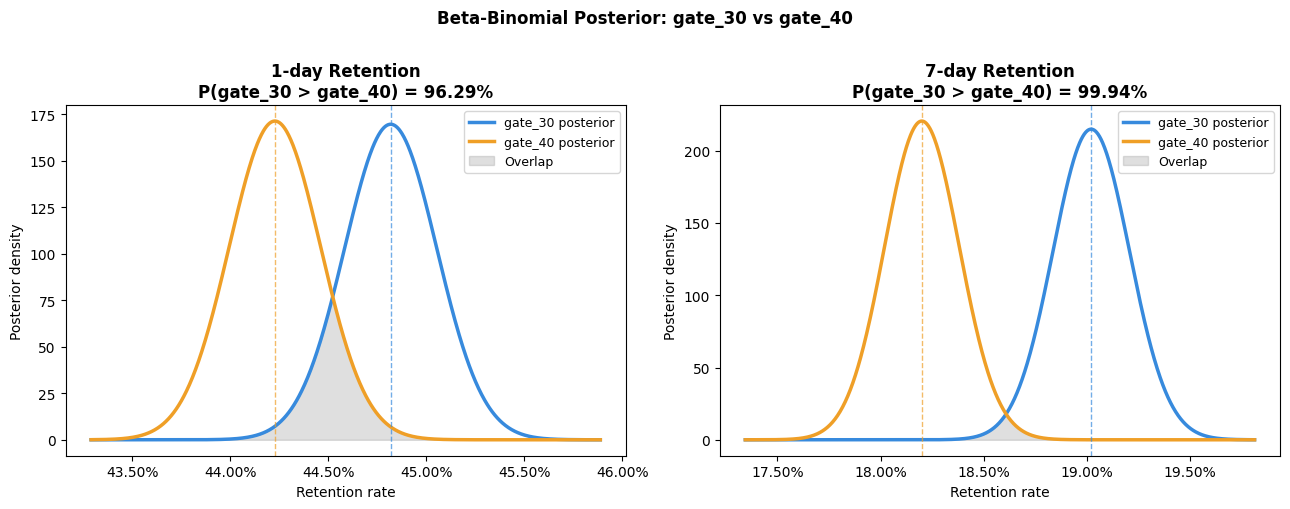

In [3]:
##Posterior density plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, outcome, title in zip(axes,
    ['retention_1', 'retention_7'],
    ['1-day Retention', '7-day Retention']):

    r = results[outcome]
    
    # Vẽ posterior density
    x_min = min(r['samples_30'].min(), r['samples_40'].min())
    x_max = max(r['samples_30'].max(), r['samples_40'].max())
    x = np.linspace(x_min, x_max, 1000)

    sub = ab[ab['outcome'] == outcome]
    a = sub[sub['version']=='gate_30'].iloc[0]
    b = sub[sub['version']=='gate_40'].iloc[0]

    post_30 = stats.beta(1 + a['successes'], 1 + a['failures'])
    post_40 = stats.beta(1 + b['successes'], 1 + b['failures'])

    ax.plot(x, post_30.pdf(x), color=COLORS['gate_30'], lw=2.5, label='gate_30 posterior')
    ax.plot(x, post_40.pdf(x), color=COLORS['gate_40'], lw=2.5, label='gate_40 posterior')

    # Vùng chồng lấp
    y_min_overlap = np.minimum(post_30.pdf(x), post_40.pdf(x))
    ax.fill_between(x, y_min_overlap, alpha=0.25, color='gray', label='Overlap')

    # Vertical line tại mean mỗi posterior
    ax.axvline(a['rate'], color=COLORS['gate_30'], lw=1, linestyle='--', alpha=0.7)
    ax.axvline(b['rate'], color=COLORS['gate_40'], lw=1, linestyle='--', alpha=0.7)

    ax.set_title(f'{title}\nP(gate_30 > gate_40) = {r["p_30_wins"]*100:.2f}%',
                 fontweight='bold')
    ax.set_xlabel('Retention rate')
    ax.set_ylabel('Posterior density')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=9)

plt.suptitle('Beta-Binomial Posterior: gate_30 vs gate_40',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/posterior_density.png', dpi=120, bbox_inches='tight')
plt.show()

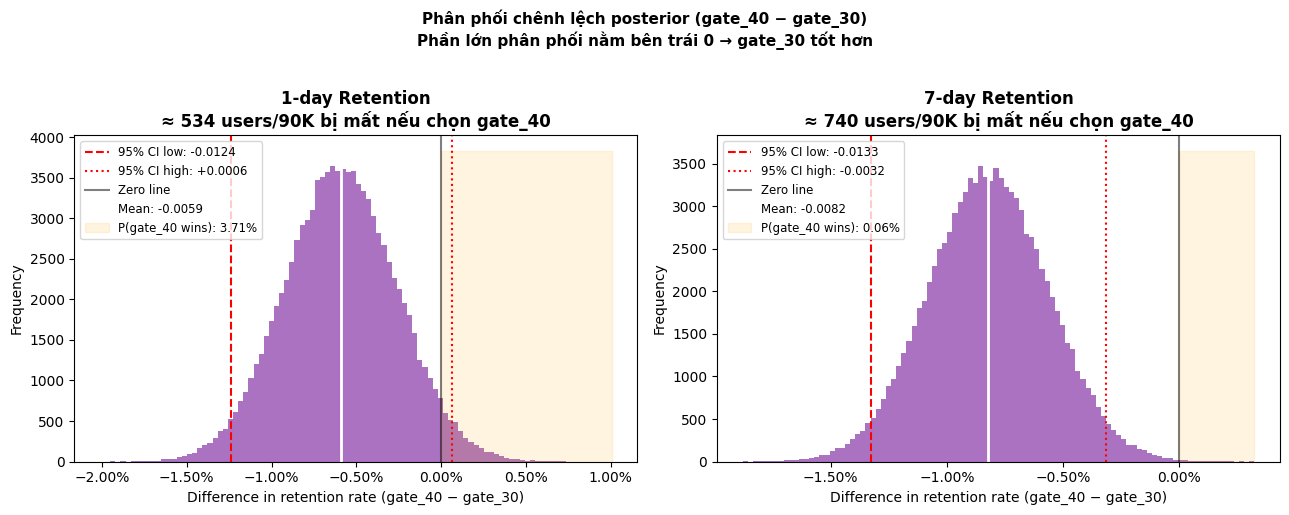

=== BUSINESS SUMMARY ===

retention_1:
  Nếu chọn gate_40 thay gate_30:
  → Mất ≈ 534 users không quay lại (trên 90K users)
  → Rủi ro quyết định sai: 3.71%
  → Expected loss: 0.597pp

retention_7:
  Nếu chọn gate_40 thay gate_30:
  → Mất ≈ 740 users không quay lại (trên 90K users)
  → Rủi ro quyết định sai: 0.06%
  → Expected loss: 0.821pp


In [4]:
#Diff distribution + business translation
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, outcome, title in zip(axes,
    ['retention_1', 'retention_7'],
    ['1-day Retention', '7-day Retention']):

    r = results[outcome]
    diff = r['diff']  # gate_40 - gate_30 (negative = gate_30 tốt hơn)

    ax.hist(diff, bins=100, color='#9B59B6', edgecolor='none', alpha=0.85)

    # CI lines
    ax.axvline(r['ci_low'],  color='red', lw=1.5, linestyle='--', label=f"95% CI low: {r['ci_low']:+.4f}")
    ax.axvline(r['ci_high'], color='red', lw=1.5, linestyle=':',  label=f"95% CI high: {r['ci_high']:+.4f}")
    ax.axvline(0, color='black', lw=1.5, alpha=0.5, label='Zero line')
    ax.axvline(r['diff_mean'], color='white', lw=2, linestyle='-', label=f"Mean: {r['diff_mean']:+.4f}")

    # Tô vùng gate_40 thắng (diff > 0)
    ax.fill_betweenx(
        [0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 3000],
        0, diff.max(),
        alpha=0.12, color='orange', label=f"P(gate_40 wins): {r['p_40_wins']*100:.2f}%"
    )

    # Business translation annotation
    n_users = 90189
    users_lost = abs(r['diff_mean']) * n_users
    ax.set_title(f'{title}\n≈ {users_lost:,.0f} users/90K bị mất nếu chọn gate_40',
                 fontweight='bold')
    ax.set_xlabel('Difference in retention rate (gate_40 − gate_30)')
    ax.set_ylabel('Frequency')
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8.5)

plt.suptitle('Phân phối chênh lệch posterior (gate_40 − gate_30)\nPhần lớn phân phối nằm bên trái 0 → gate_30 tốt hơn',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/posterior_diff_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# Business summary
print("=== BUSINESS SUMMARY ===")
for outcome, r in results.items():
    n = 90189
    print(f"\n{outcome}:")
    print(f"  Nếu chọn gate_40 thay gate_30:")
    print(f"  → Mất ≈ {abs(r['diff_mean'])*n:,.0f} users không quay lại (trên 90K users)")
    print(f"  → Rủi ro quyết định sai: {r['p_40_wins']*100:.2f}%")
    print(f"  → Expected loss: {r['expected_loss_if_choose_40']*100:.3f}pp")

In [5]:
summary_rows = []
for outcome, r in results.items():
    summary_rows.append({
        'outcome': outcome,
        'p_30_wins': r['p_30_wins'],
        'p_40_wins': r['p_40_wins'],
        'diff_mean': r['diff_mean'],
        'ci_low': r['ci_low'],
        'ci_high': r['ci_high'],
        'expected_loss_choose_40': r['expected_loss_if_choose_40'],
        'expected_loss_choose_30': r['expected_loss_if_choose_30'],
    })

bayesian_results = pd.DataFrame(summary_rows)
bayesian_results.to_csv('../app/bayesian_results.csv', index=False)
print("✓ Đã lưu app/bayesian_results.csv\n")
print(bayesian_results.to_string(index=False))

✓ Đã lưu app/bayesian_results.csv

    outcome  p_30_wins  p_40_wins  diff_mean    ci_low   ci_high  expected_loss_choose_40  expected_loss_choose_30
retention_1    0.96289    0.03711  -0.005917 -0.012382  0.000613                 0.005967             5.018459e-05
retention_7    0.99937    0.00063  -0.008210 -0.013261 -0.003158                 0.008210             4.437526e-07
